Installing PySpark and importing requirements

In [37]:
# Install & Import PySpark

!pip install pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, isnan, count
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Create Spark session
spark = SparkSession.builder.appName("AcademicStressPipeline").getOrCreate()


Loading Dataset

In [38]:

df = spark.read.csv("AcademicStressLevelData.csv", header=True, inferSchema=True)

print("Schema:")
df.printSchema()
df.show(5, truncate=False)


Schema:
root
 |-- Timestamp: string (nullable = true)
 |-- Your Academic Stage: string (nullable = true)
 |-- Peer pressure: integer (nullable = true)
 |-- Academic pressure from your home: integer (nullable = true)
 |-- Study Environment: string (nullable = true)
 |-- What coping strategy you use as a student?: string (nullable = true)
 |-- Do you have any bad habits like smoking, drinking on a daily basis?: string (nullable = true)
 |-- What would you rate the academic  competition in your student life: integer (nullable = true)
 |-- Rate your academic stress index : integer (nullable = true)

+-------------------+-------------------+-------------+--------------------------------+-----------------+--------------------------------------------------+-------------------------------------------------------------------+------------------------------------------------------------------+--------------------------------+
|Timestamp          |Your Academic Stage|Peer pressure|Academic pressur

Preprocessing the data using dropna() function

In [39]:
# Check missing values
df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns]).show()

# Drop rows with nulls
df_clean = df.dropna(how="any")


+---------+-------------------+-------------+--------------------------------+-----------------+------------------------------------------+-------------------------------------------------------------------+------------------------------------------------------------------+--------------------------------+
|Timestamp|Your Academic Stage|Peer pressure|Academic pressure from your home|Study Environment|What coping strategy you use as a student?|Do you have any bad habits like smoking, drinking on a daily basis?|What would you rate the academic  competition in your student life|Rate your academic stress index |
+---------+-------------------+-------------+--------------------------------+-----------------+------------------------------------------+-------------------------------------------------------------------+------------------------------------------------------------------+--------------------------------+
|        0|                  0|            0|                               

Feature Engineering :
      To calculate Stress index of the students and ranking them to High, Medium and Low

In [25]:
df_processed = (
    df_clean
    .withColumn("EnvScore", when(col("Study Environment")=="Noisy", 2).otherwise(1))
    .withColumn("CopingScore", when(col("What coping strategy you use as a student?").like("%Social%"), -1)
                .when(col("What coping strategy you use as a student?").like("%Analyze%"), 0)
                .otherwise(1))
    .withColumn("HabitScore", when(col("Do you have any bad habits like smoking, drinking on a daily basis?")=="Yes", 2).otherwise(0))
)

df_final = df_processed.withColumn(
    "CalculatedStressLevel",
    col("Peer pressure") +
    col("Academic pressure from your home") +
    col("What would you rate the academic  competition in your student life") +
    col("EnvScore") +
    col("HabitScore") +
    col("CopingScore")
)

df_final = df_final.withColumn(
    "StressCategory",
    when(col("CalculatedStressLevel") <= 6, "Low")
    .when((col("CalculatedStressLevel") > 6) & (col("CalculatedStressLevel") <= 12), "Medium")
    .otherwise("High")
)
print("Successfully Done!!!")


Successfully Done!!!


Exploratory Data Analysis(EDA):

Computing average stress level per academic stage.

/tmp/ipython-input-3610366693.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_stress, x="Your Academic Stage", y="AvgStress", palette="viridis")


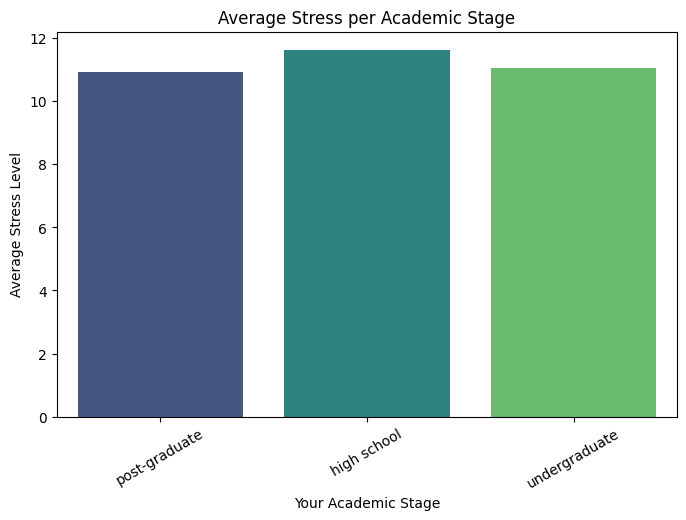

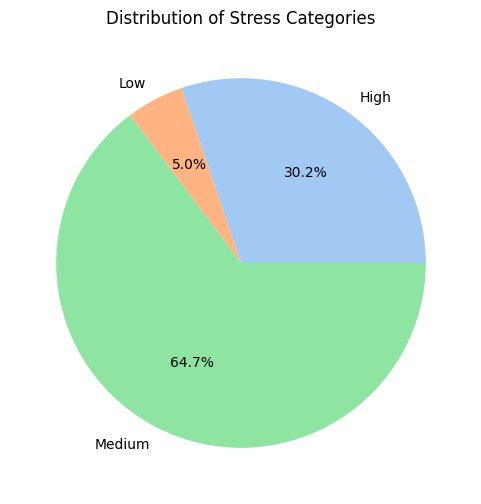

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average stress per academic stage
avg_stress = df_final.groupBy("Your Academic Stage") \
                     .agg(avg("CalculatedStressLevel").alias("AvgStress")) \
                     .toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_stress, x="Your Academic Stage", y="AvgStress", palette="viridis")
plt.title("Average Stress per Academic Stage")
plt.ylabel("Average Stress Level")
plt.xticks(rotation=30)
plt.show()

# Distribution of Stress Categories
stress_dist = df_final.groupBy("StressCategory").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(stress_dist["count"], labels=stress_dist["StressCategory"], autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Distribution of Stress Categories")
plt.show()


Clustering:

* Use VectorAssembler to combine features into one vector.

* Apply KMeans clustering with k=3 clusters.

* Compare cluster assignments with stress categories.

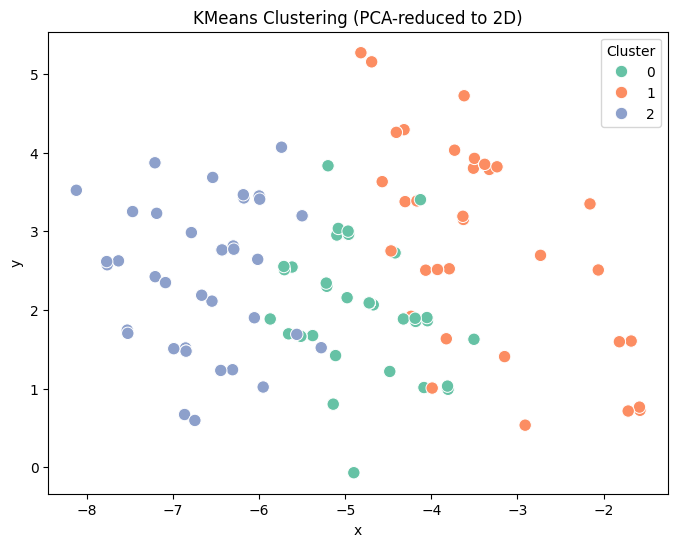

In [30]:
from pyspark.ml.feature import PCA

# Assemble features
feature_cols = ["Peer pressure","Academic pressure from your home",
                "What would you rate the academic  competition in your student life",
                "EnvScore","HabitScore","CopingScore"]

vec_assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_cluster = vec_assembler.transform(df_final)

# KMeans
kmeans = KMeans(k=3, seed=42, featuresCol="features", predictionCol="Cluster")
model = kmeans.fit(df_cluster)
df_clustered = model.transform(df_cluster)

# Reduce dimensions for visualization using PCA
pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
pca_model = pca.fit(df_clustered)
df_pca = pca_model.transform(df_clustered).select("pcaFeatures","Cluster").toPandas()

# Extract PCA coords
df_pca["x"] = df_pca["pcaFeatures"].apply(lambda v: float(v[0]))
df_pca["y"] = df_pca["pcaFeatures"].apply(lambda v: float(v[1]))

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x="x", y="y", hue="Cluster", palette="Set2", s=80)
plt.title("KMeans Clustering (PCA-reduced to 2D)")
plt.show()



Prediction:

Used StringIndexer to convert stress categories (Low, Medium, High) into numeric labels.

Splited dataset into training (**70%**) and testing (**30%**).

Trained two models:

     1.Decision Tree Classifier

     2.Random Forest Classifier


* Supervised ML = model learns from labeled data.

* Decision Tree = simple, interpretable model (like yes/no questions).

* Random Forest = collection of many decision trees → usually more accurate.

* Splitting ensures the model is tested on new unseen data.

Evaluation:

* Evaluating model performance using accuracy.

* Comparing Decision Tree vs Random Forest.

Prediction Successfull!!!
Decision Tree Accuracy: 0.86
Random Forest Accuracy: 0.89
Random Forest Feature Importances:
(6,[0,1,2,3,4,5],[0.3082310440613897,0.3354370947996689,0.1091628077718676,0.026232454382207733,0.10403520545076976,0.11690139353409641])


/tmp/ipython-input-2356958815.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_df, x="Model", y="Accuracy", palette="coolwarm")


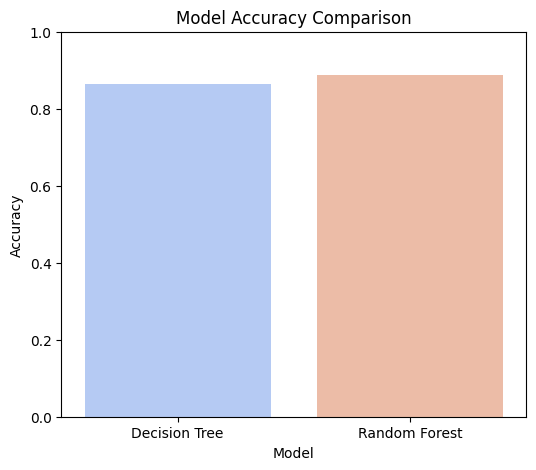

/tmp/ipython-input-2356958815.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x="Importance", y="Feature", palette="mako")


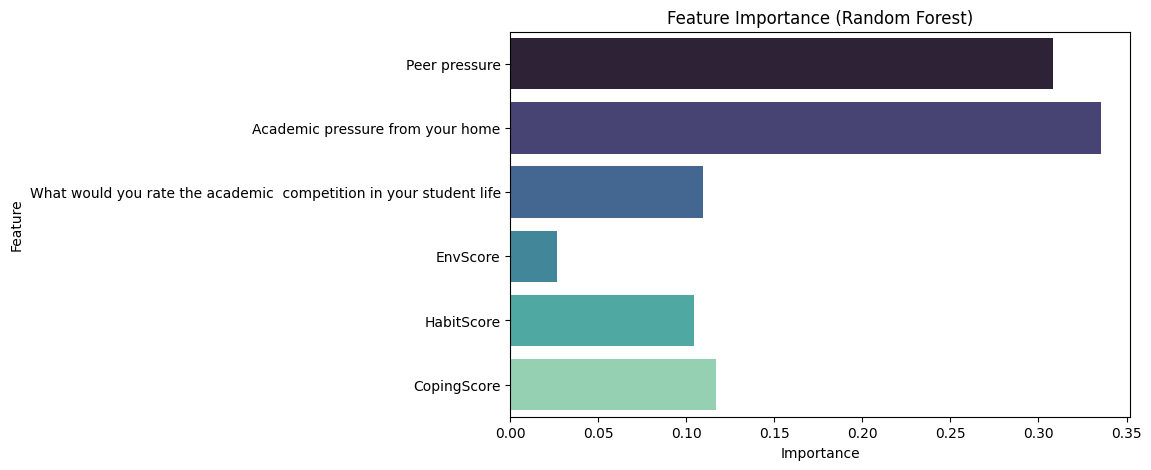

In [36]:
# Convert target column to numeric
indexer = StringIndexer(inputCol="StressCategory", outputCol="label")
df_ml = indexer.fit(df_clustered).transform(df_clustered)

# Split dataset
train, test = df_ml.randomSplit([0.7, 0.3], seed=42)

# Decision Tree
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")
dt_model = dt.fit(train)
dt_preds = dt_model.transform(test)

# Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50, seed=42)
rf_model = rf.fit(train)
rf_preds = rf_model.transform(test)
print("Prediction Successfull!!!")

# Evaluation


evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

dt_acc = evaluator.evaluate(dt_preds)
rf_acc = evaluator.evaluate(rf_preds)

print(f"Decision Tree Accuracy: {dt_acc:.2f}")
print(f"Random Forest Accuracy: {rf_acc:.2f}")

print("Random Forest Feature Importances:")
print(rf_model.featureImportances)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acc_results = {"Model": ["Decision Tree", "Random Forest"],
               "Accuracy": [dt_acc, rf_acc]}
acc_df = pd.DataFrame(acc_results)

plt.figure(figsize=(6,5))
sns.barplot(data=acc_df, x="Model", y="Accuracy", palette="coolwarm")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

# Random Forest Feature Importances
importances = rf_model.featureImportances.toArray()
feature_importances = pd.DataFrame({"Feature": feature_cols, "Importance": importances})

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importances, x="Importance", y="Feature", palette="mako")
plt.title("Feature Importance (Random Forest)")
plt.show()
